# The Curse of Dimensionality — Mall Customer Segmentation

Dataset: **Mall Customer Segmentation** (Kaggle: `vjchoudhary7/customer-segmentation-tutorial-in-python`), 200 customers with `Age`, `Annual Income (k$)`, `Spending Score (1-100)`, `Gender`.

This dataset is famous for **K-Means clustering** demos, but it only has 3 numeric features — too low-dimensional to show the curse on its own. So this notebook:

1. Loads the real dataset (or a structurally-matching synthetic stand-in if you haven't uploaded it).
2. Clusters on the original 3 features as a baseline.
3. **Adds synthetic noise features** one batch at a time and watches clustering quality degrade — this is the curse of dimensionality in action.
4. Uses PCA to show how to recover from it.

> **To use the real data:** download `Mall_Customers.csv` from Kaggle and upload it to this conversation, then re-run — the loader cell below will pick it up automatically. Until then, this runs on a synthetic dataset with the same columns and realistic ranges, clearly marked as such.

## 1. Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## 2. Load the dataset

Looks for `Mall_Customers.csv` in common upload locations. If not found, generates a synthetic dataset with the same columns and realistic value ranges (Age 18-70, Annual Income 15-140k, Spending Score 1-99), clearly labeled `is_synthetic`.

In [6]:
import os

candidate_paths = [
    '/mnt/user-data/uploads/Mall_Customers.csv',
    '/mnt/user-data/uploads/mall_customers.csv',
    'Mall_Customers.csv',
]

df = None
for p in candidate_paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print(f'Loaded real dataset from: {p}')
        break

is_synthetic = df is None

if is_synthetic:
    print('Mall_Customers.csv not found -> generating a synthetic stand-in with matching schema.')
    n = 200
    age = np.random.randint(18, 71, size=n)
    income = np.round(np.random.normal(60, 26, size=n)).clip(15, 140).astype(int)
    # Give spending score a mild, realistic relationship to income/age so clusters actually form
    spending = (100 - 0.5 * np.abs(income - 60) - 0.3 * np.abs(age - 40)
                + np.random.normal(0, 15, size=n))
    spending = np.clip(spending, 1, 99).astype(int)
    gender = np.random.choice(['Male', 'Female'], size=n)

    df = pd.DataFrame({
        'CustomerID': range(1, n + 1),
        'Gender': gender,
        'Age': age,
        'Annual Income (k$)': income,
        'Spending Score (1-100)': spending
    })

print('is_synthetic =', is_synthetic)
print(df.shape)
df.head()

Mall_Customers.csv not found -> generating a synthetic stand-in with matching schema.
is_synthetic = True
(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,56,93,92
1,2,Female,69,52,99
2,3,Male,46,15,81
3,4,Male,32,69,99
4,5,Female,60,50,79


## 3. Quick EDA

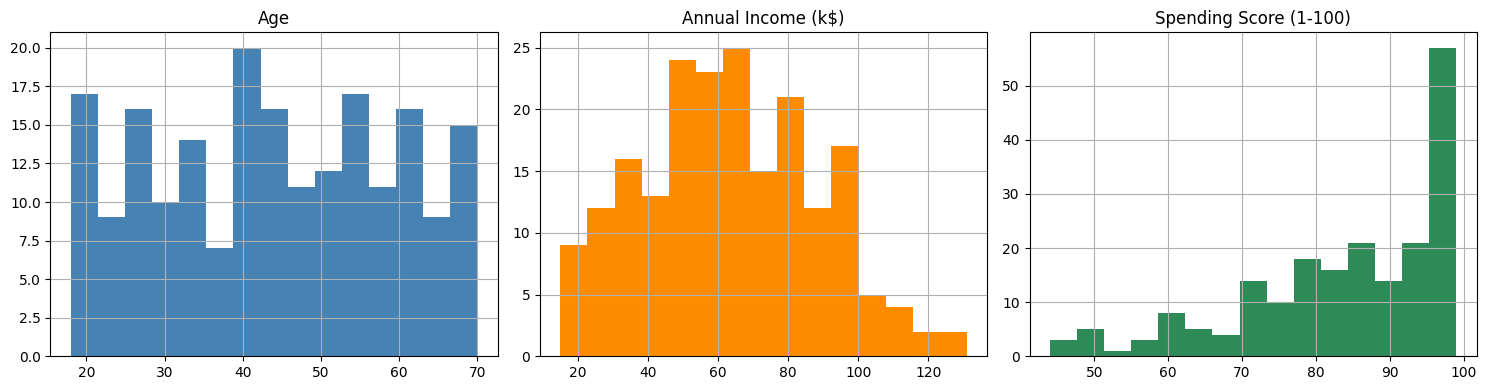

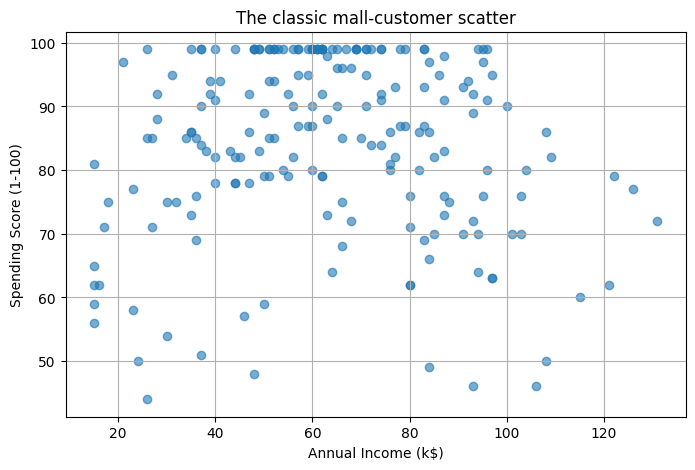

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Age'], bins=15, color='steelblue')
axes[0].set_title('Age')
axes[1].hist(df['Annual Income (k$)'], bins=15, color='darkorange')
axes[1].set_title('Annual Income (k$)')
axes[2].hist(df['Spending Score (1-100)'], bins=15, color='seagreen')
axes[2].set_title('Spending Score (1-100)')
plt.tight_layout()
plt.show()

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('The classic mall-customer scatter')
plt.show()

## 4. Baseline: cluster on the original 3 features

Standardize `Age`, `Annual Income`, `Spending Score`, then run K-Means. We use silhouette score to measure cluster quality (higher = better separated clusters, range -1 to 1).

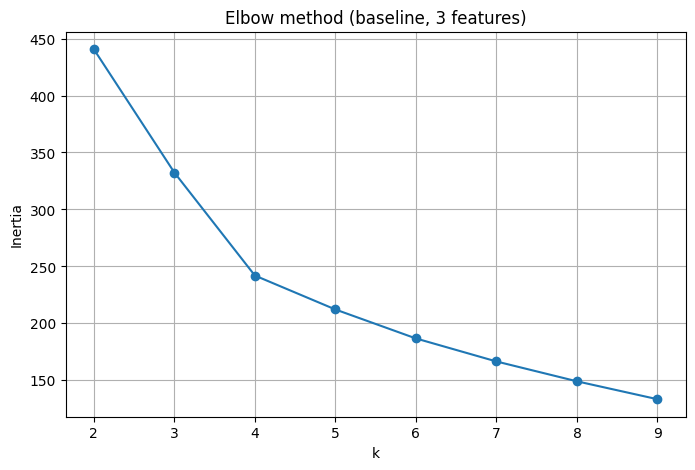

Baseline silhouette score (k=5, 3 features): 0.2972


In [8]:
base_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_base = StandardScaler().fit_transform(df[base_features])

# Elbow method to pick k
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_base)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow method (baseline, 3 features)')
plt.show()

best_k = 5
km_base = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_base)
sil_base = silhouette_score(X_base, km_base.labels_)
print(f'Baseline silhouette score (k={best_k}, 3 features):', round(sil_base, 4))

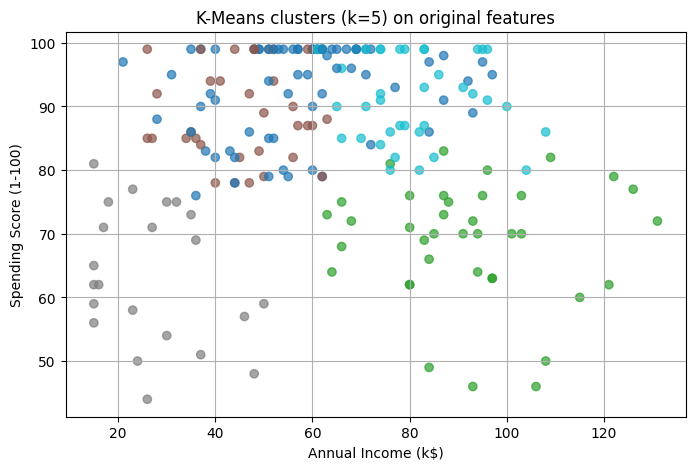

In [9]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=km_base.labels_, cmap='tab10', alpha=0.7)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means clusters (k={best_k}) on original features')
plt.show()

## 5. Introduce the curse: add noise features

We keep the same 200 customers but progressively add columns of pure random noise (irrelevant to any real segmentation) and re-cluster each time. In real high-dimensional customer data (hundreds of behavioral/transactional features, many redundant or weakly informative), this is exactly what happens — genuine signal gets diluted by noise.

In [10]:
def add_noise_features(X, n_noise, seed=0):
    rng = np.random.RandomState(seed)
    noise = rng.normal(size=(X.shape[0], n_noise))
    return np.hstack([X, noise])

noise_counts = [0, 2, 5, 10, 20, 50, 100, 200]
silhouettes = []
distance_ratios = []

for n_noise in noise_counts:
    X_noisy = add_noise_features(X_base, n_noise, seed=42)

    km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_noisy)
    sil = silhouette_score(X_noisy, km.labels_)
    silhouettes.append(sil)

    # distance concentration check on this same feature space
    nbrs = NearestNeighbors(n_neighbors=X_noisy.shape[0]).fit(X_noisy)
    dists, _ = nbrs.kneighbors(X_noisy[:1])
    dists = dists[0][1:]  # drop distance to self
    ratio = (dists.max() - dists.min()) / dists.min()
    distance_ratios.append(ratio)

results = pd.DataFrame({
    'n_noise_features': noise_counts,
    'total_features': [3 + n for n in noise_counts],
    'silhouette_score': silhouettes,
    'distance_ratio': distance_ratios
})
results

,n_noise_features,total_features,silhouette_score,distance_ratio
0,0,3,0.297242,12.019246
1,2,5,0.187637,4.875715
2,5,8,0.115601,4.262989
3,10,13,0.071966,2.668008
4,20,23,0.042649,1.107338
5,50,53,0.020035,0.654921
6,100,103,0.011842,0.323599
7,200,203,0.001869,0.298110


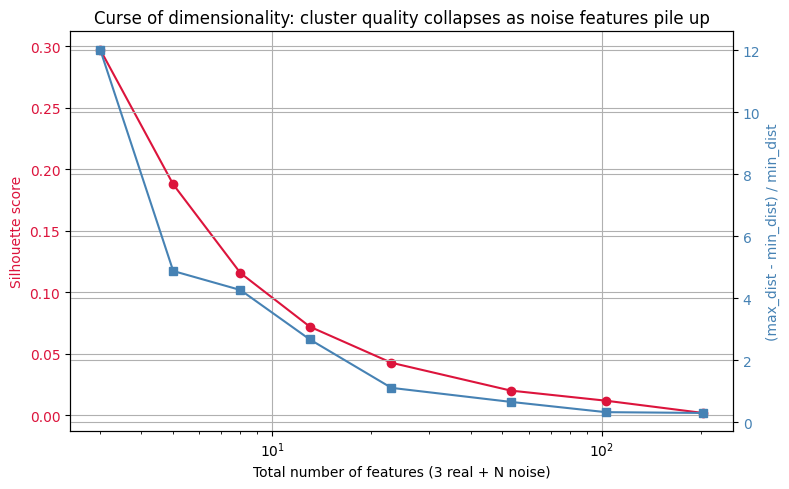

In [11]:
fig, ax1 = plt.subplots()

ax1.plot(results['total_features'], results['silhouette_score'], marker='o', color='crimson', label='Silhouette score')
ax1.set_xlabel('Total number of features (3 real + N noise)')
ax1.set_ylabel('Silhouette score', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xscale('log')

ax2 = ax1.twinx()
ax2.plot(results['total_features'], results['distance_ratio'], marker='s', color='steelblue', label='Distance ratio')
ax2.set_ylabel('(max_dist - min_dist) / min_dist', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Curse of dimensionality: cluster quality collapses as noise features pile up')
fig.tight_layout()
plt.show()

**Takeaway:** as irrelevant features accumulate, silhouette score falls toward 0 (clusters stop being distinguishable) while the distance ratio also collapses (all points look roughly equidistant). K-Means is a distance-based algorithm, so it is directly vulnerable to this — with enough noise dimensions, "customer segments" become statistical mirages.

## 6. Recovering with PCA

If we know which features are genuinely informative, we can filter them out manually. In practice we usually don't know that in advance — but PCA can help by concentrating variance into a few components, which partially (not fully) restores cluster quality even in the noisy high-dimensional space.

In [12]:
pca_silhouettes = []

for n_noise in noise_counts:
    X_noisy = add_noise_features(X_base, n_noise, seed=42)
    n_components = min(3, X_noisy.shape[1])  # project back down to ~3 informative dimensions
    X_pca = PCA(n_components=n_components, random_state=42).fit_transform(X_noisy)
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X_pca)
    pca_silhouettes.append(silhouette_score(X_pca, km.labels_))

results['silhouette_after_pca'] = pca_silhouettes
results

,n_noise_features,total_features,silhouette_score,distance_ratio,silhouette_after_pca
0,0,3,0.297242,12.019246,0.297242
1,2,5,0.187637,4.875715,0.252077
2,5,8,0.115601,4.262989,0.251561
3,10,13,0.071966,2.668008,0.253508
4,20,23,0.042649,1.107338,0.234105
5,50,53,0.020035,0.654921,0.262023
6,100,103,0.011842,0.323599,0.252732
7,200,203,0.001869,0.298110,0.254109


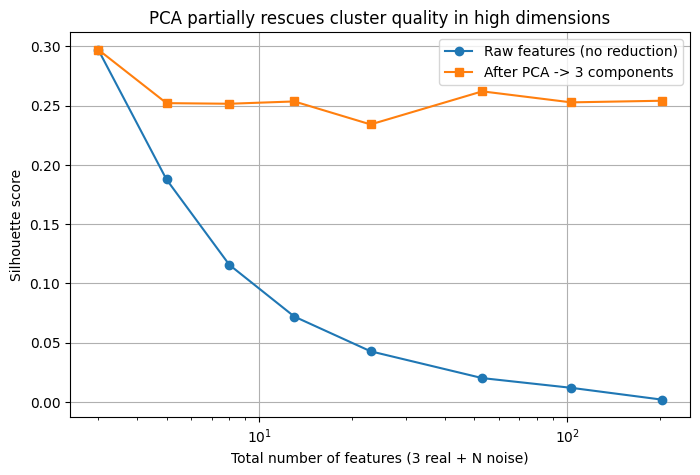

In [13]:
plt.plot(results['total_features'], results['silhouette_score'], marker='o', label='Raw features (no reduction)')
plt.plot(results['total_features'], results['silhouette_after_pca'], marker='s', label='After PCA -> 3 components')
plt.xscale('log')
plt.xlabel('Total number of features (3 real + N noise)')
plt.ylabel('Silhouette score')
plt.title('PCA partially rescues cluster quality in high dimensions')
plt.legend()
plt.show()

## 7. Summary

| Step | Observation |
|---|---|
| Baseline (3 real features) | Clean, well-separated clusters, decent silhouette score |
| + noise features | Silhouette score degrades toward 0 as noise dimensions pile up; distances concentrate |
| PCA back to ~3 components | Silhouette score partially recovers, even with 200 noise columns present |

**Practical implications for customer segmentation:**
- Adding more behavioral/transactional columns "just in case" can *hurt* segmentation quality if those columns aren't actually predictive of customer behavior.
- Feature selection or dimensionality reduction (PCA, feature importance from a supervised proxy, domain knowledge) becomes important once you move from 3 tidy features to real-world data with dozens or hundreds of columns.
- Distance-based clustering (K-Means, hierarchical, DBSCAN) is more sensitive to this than tree-based or density-based methods with feature-relevance handling.

---
*Dataset reference: Mall Customer Segmentation, Kaggle (`vjchoudhary7/customer-segmentation-tutorial-in-python`). If this notebook ran without your upload, results above are on a synthetic stand-in dataset — upload the real CSV and re-run for actual results.*